# 📊 Portofolio: User Retention & Cohort Analysis

**Tujuan Proyek:**
Mengevaluasi efektivitas bisnis dalam mempertahankan pelanggan lama dengan menganalisis pola transaksi berulang (retensi) dari waktu ke waktu.

## 1. Import Library dan Dataset
Langkah pertama adalah memanggil library yang dibutuhkan dan memuat dataset ke dalam dataframe pandas.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
PATH_FILE = '/content/drive/MyDrive/Project User Retention Analysis/Salinan Online Retail Data.csv'

# Jika pakai VS Code / Local, gunakan path langsung:
#PATH_FILE = 'Salinan Online Retail Data.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from operator import attrgetter

# Load dataset
df = pd.read_csv(PATH_FILE)

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
df.head()

Mounted at /content/drive


,order_id,product_code,product_name,quantity,order_date,price,customer_id
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.85,NaN
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.75,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB


## 2. Exploratory Data Analysis (EDA)
Sebelum mengolah data, kita perlu memahami karakteristik data, mengecek apakah ada nilai yang kosong (*missing values*), dan mencari data duplikat.

In [3]:
# Mengecek informasi dataset (jumlah baris, kolom, dan tipe data)
print("--- INFO DATASET ---")
df.info()

print("\n--- MISSING VALUES ---")
# Mengecek jumlah data yang kosong di setiap kolom
print(df.isnull().sum())

print("\n--- DATA DUPLIKAT ---")
# Mengecek jumlah baris yang duplikat
print("Jumlah duplikat:", df.duplicated().sum())

--- INFO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB

--- MISSING VALUES ---
order_id             0
product_code         0
product_name      2718
quantity             0
order_date           0
price                0
customer_id     100920
dtype: int64

--- DATA DUPLIKAT ---
Jumlah duplikat: 6479


## 3. Data Cleansing
Berdasarkan hasil EDA, kita perlu membersihkan data. Langkah utama dalam analisis retensi pengguna adalah memastikan tidak ada `customer_id` yang kosong, lalu mengubah format tanggal transaksi agar bisa diolah untuk analisis bulanan.

In [6]:
# Membuat salinan data agar data asli tidak berubah
df_clean = df.copy()

# 1. Menghapus baris yang tidak memiliki customer_id
df_clean = df_clean.dropna(subset=['customer_id'])

# 2. Menghapus data duplikat (jika ada)
df_clean = df_clean.drop_duplicates()

# 3. PERBAIKAN: Menggunakan 'order_date' (dengan garis bawah)
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])

# 4. Membuat kolom 'year_month' untuk melihat pola transaksi bulanan
df_clean['year_month'] = df_clean['order_date'].dt.to_period('M')

# Menampilkan hasil data yang sudah bersih
df_clean.head()

,order_id,product_code,product_name,quantity,order_date,price,customer_id,year_month
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0,2010-01
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0,2010-01
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0,2010-01
6,493414,21844,RETRO SPOT MUG,36,2010-01-04 10:28:00,2.55,14590.0,2010-01
7,493414,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-04 10:28:00,4.25,14590.0,2010-01


## 4. Membuat User Retention Cohort
Di tahap ini, kita akan mengagregasi data transaksi untuk menemukan bulan pertama setiap pengguna bertransaksi (Cohort), lalu menghitung jarak bulan untuk melihat retensi mereka.

In [7]:
# Agregasi data transaksi ke bentuk summary total transaksi/order setiap pengguna setiap bulan
df_user_monthly = df_clean.groupby(['customer_id','year_month'], as_index=False).agg(order_cnt=('order_id','nunique'))
df_user_monthly.head()

,customer_id,year_month,order_cnt
0,12346.0,2010-01,5
1,12346.0,2010-03,1
2,12346.0,2010-06,2
3,12346.0,2010-10,2
4,12608.0,2010-10,1


In [8]:
# Buat kolom sebagai cohort dari pengguna, yaitu bulan pertama kali bertransaksi
df_user_monthly['cohort'] = df_user_monthly.groupby('customer_id')['year_month'].transform('min')
df_user_monthly.head()

,customer_id,year_month,order_cnt,cohort
0,12346.0,2010-01,5,2010-01
1,12346.0,2010-03,1,2010-01
2,12346.0,2010-06,2,2010-01
3,12346.0,2010-10,2,2010-01
4,12608.0,2010-10,1,2010-10


In [9]:
# Hitung jarak bulan antara bulan transaksi dengan bulan pertama kali transaksi
# dan jumlahkan dengan 1 agar jarak bulan 0 menjadi 1 (bulan pertama)
df_user_monthly['period_num'] = (df_user_monthly['year_month'] - df_user_monthly['cohort']).apply(attrgetter('n')) + 1
df_user_monthly.head()

,customer_id,year_month,order_cnt,cohort,period_num
0,12346.0,2010-01,5,2010-01,1
1,12346.0,2010-03,1,2010-01,3
2,12346.0,2010-06,2,2010-01,6
3,12346.0,2010-10,2,2010-01,10
4,12608.0,2010-10,1,2010-10,1


In [14]:
cohort_size = df_cohort_pivot.iloc[:, 0]
cohort_size

,1
cohort,
2010-01,719.0
2010-02,464.0
2010-03,540.0
2010-04,333.0
2010-05,275.0
2010-06,278.0
2010-07,180.0
2010-08,160.0
2010-09,232.0


In [10]:
# Tabel pivot dengan index berupa cohort, kolom berupa jarak bulan,
# dan nilainya adalah banyaknya pengguna unik (count unique dari ID pengguna)
df_cohort_pivot = pd.pivot_table(df_user_monthly, index='cohort', columns='period_num', values='customer_id', aggfunc=pd.Series.nunique)
df_cohort_pivot

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,719.0,284.0,338.0,319.0,310.0,310.0,296.0,273.0,292.0,331.0,341.0,254.0
2010-02,464.0,155.0,128.0,165.0,152.0,123.0,121.0,161.0,155.0,168.0,101.0,NaN
2010-03,540.0,146.0,160.0,146.0,140.0,125.0,150.0,189.0,195.0,99.0,NaN,NaN
2010-04,333.0,82.0,76.0,63.0,71.0,80.0,99.0,102.0,51.0,NaN,NaN,NaN
2010-05,275.0,56.0,50.0,53.0,51.0,73.0,66.0,43.0,NaN,NaN,NaN,NaN
2010-06,278.0,55.0,56.0,59.0,64.0,85.0,38.0,NaN,NaN,NaN,NaN,NaN
2010-07,180.0,39.0,37.0,52.0,53.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,160.0,35.0,50.0,48.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,232.0,67.0,61.0,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Hitung banyaknya pengguna di masing-masing cohort (pengguna yang pertama kali transaksi di bulan tersebut)
cohort_size = df_cohort_pivot.iloc[:, 0]

# Bagi semua nilai di tabel pivot tadi dengan nilai cohort_size sebagai retention rate
df_retention_cohort = df_cohort_pivot.divide(cohort_size, axis=0)
df_retention_cohort

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,1.0,0.394993,0.470097,0.443672,0.431154,0.431154,0.411683,0.379694,0.406120,0.460362,0.474270,0.353268
2010-02,1.0,0.334052,0.275862,0.355603,0.327586,0.265086,0.260776,0.346983,0.334052,0.362069,0.217672,NaN
2010-03,1.0,0.270370,0.296296,0.270370,0.259259,0.231481,0.277778,0.350000,0.361111,0.183333,NaN,NaN
2010-04,1.0,0.246246,0.228228,0.189189,0.213213,0.240240,0.297297,0.306306,0.153153,NaN,NaN,NaN
2010-05,1.0,0.203636,0.181818,0.192727,0.185455,0.265455,0.240000,0.156364,NaN,NaN,NaN,NaN
2010-06,1.0,0.197842,0.201439,0.212230,0.230216,0.305755,0.136691,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.216667,0.205556,0.288889,0.294444,0.172222,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.218750,0.312500,0.300000,0.168750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,1.0,0.288793,0.262931,0.137931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Visualisasi Cohort Retention
Menampilkan tabel pivot yang sudah berisi nilai *retention rate* ke dalam bentuk *Heatmap* agar pola retensi pelanggan lebih mudah dipahami secara visual.

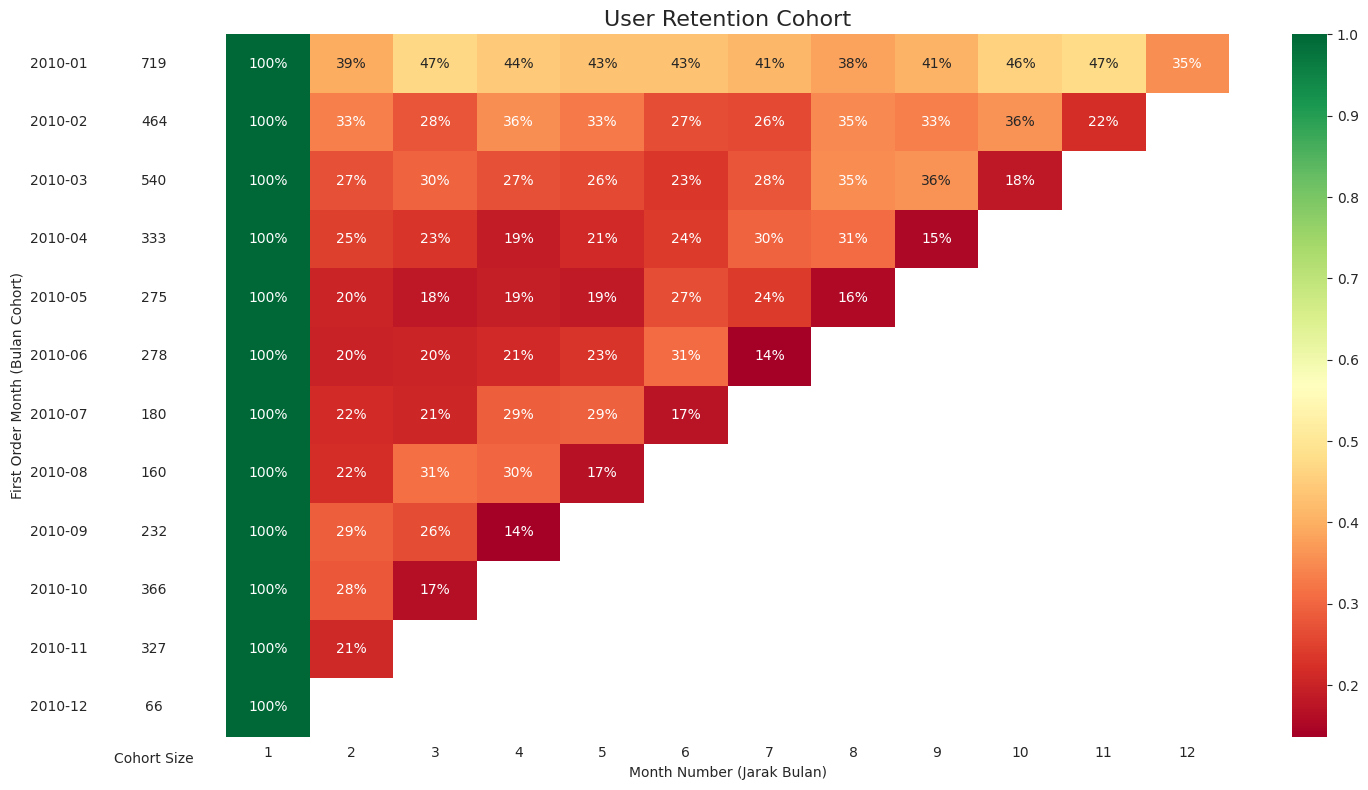

In [12]:
# Pastikan library sudah diimport sebelumnya
with sns.axes_style('white'):
    # Membuat figure dengan dua area (untuk Cohort Size dan Retention Heatmap)
    fig, ax = plt.subplots(1, 2, figsize=(15, 8), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # 1. Plot User Retention Cohort Heatmap
    sns.heatmap(df_retention_cohort, annot=True, fmt='.0%', cmap='RdYlGn', ax=ax[1])
    ax[1].set_title('User Retention Cohort', fontsize=16)
    ax[1].set(xlabel='Month Number (Jarak Bulan)', ylabel='')

    # 2. Plot Cohort Size
    df_cohort_size = pd.DataFrame(cohort_size)
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(df_cohort_size, annot=True, cbar=False, fmt='g', cmap=white_cmap, ax=ax[0])
    ax[0].tick_params(bottom=False)
    ax[0].set(xlabel='Cohort Size', ylabel='First Order Month (Bulan Cohort)', xticklabels=[])

    fig.tight_layout()
    plt.show()

In [13]:
# 1. Simpan gambar heatmap untuk repositori GitHub
fig.savefig('heatmap_retention.png', bbox_inches='tight', dpi=300)

# 2. Ekspor data flat untuk diolah di Google Looker Studio
df_user_monthly.to_csv('Data_Retention_LookerStudio.csv', index=False)
print("✅ Gambar dan data berhasil diekspor!")

✅ Gambar dan data berhasil diekspor!


## ANALISIS USER RETETION
Berdasakarn heatmap yang dihasilkan di atas dapat ditarik kesimpulan sebagai berikut:
1. Cohort Januari 2010 adalah jawaranya: Kelompok pengguna pertama ini memiliki ukuran terbesar (719 pengguna) dan paling loyal, dengan tingkat retensi yang stabil di kisaran 35% hingga 47% selama 11 bulan ke depan.   
2. Krisis Retensi Bulan Kedua: Hampir semua cohort mengalami churn (kehilangan pelanggan) yang drastis pada bulan kedua setelah transaksi pertama. Misalnya, cohort Februari 2010 langsung anjlok ke 33%, dan cohort Maret 2010 turun ke 27%. Ini adalah celah bisnis: perusahaan sangat butuh strategi onboarding atau promo intervensi di bulan kedua.   
3. Penurunan Akuisisi Akhir Tahun: Cohort Desember 2010 sangat kecil (hanya 66 pengguna). Ini adalah anomali yang perlu disorot untuk evaluasi tim marketing di akhir tahun.   
4. Cohort user yang paling banyak bertransaksi berada pada bulan januari 2010 sebanyak 613 pengguna
5. Cohort tersebut juga menjadi user yang paling sering bertransaksi kembali pada bulan kedua (dapat dilihat dari hasil persentase bulan kedua yaitu sebesar 38%) apabila dibandingkan dengan cohort yang lain
6. Cohort tersebut juga menjadi cohort yang paling loyal dibandingkan dengan cohort yang lain karena cohort tersebut yang paling sering bertransaksi pada bulan-bulan berikutnya
7. Namun, sangat disayangkan banyak yang tidak bertransaksi kembali, terlihat dari retetion rate yang banyak di bawah 50%
8. Lalu, pada bulan Desember yang seharusnya banyak pengguna yang bertransaksi kembali justru pada bulan ini menjadi bulan yang paling rendah persentase dari pengguna yang sebelumnya telah bertransaksi.